# Fairness in Machine Learning Lab

**Group members:** Da and Ma

## Project objective

This project audits and mitigates fairness disparities in a binary
credit-risk classifier trained on the German Credit dataset.

The sensitive attribute is age:

- **Young:** age < 25
- **Old:** age >= 25

The prediction target is:

- **1:** good credit
- **0:** bad credit

## Fairness families examined

1. **Independence:** demographic parity
2. **Separation:** equal opportunity and equalized odds
3. **Sufficiency:** predictive parity and calibration

## Normative principle

This notebook does not search for a universally fairest model.

For every metric and mitigation, we will ask:

1. Which definition of fairness does it optimise?
2. What happens to the other fairness definitions?
3. What predictive cost is incurred?
4. Which people bear that cost?

## Reproducibility rules

Throughout the project, we will use:

- one fixed random seed;
- one fixed train/test split;
- one consistent positive-class definition;
- one consistent age-group definition;
- the same test observations for comparable models;
- age retained separately for auditing, even when removed from the
  predictive features.

Generated tables will be saved in:

`outputs/tables/`

Generated figures will be saved in:

`outputs/figures/`

Saved models and preprocessing objects will be placed in:

`outputs/models/`

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
import sklearn

In [2]:
# Find the project root robustly.
#
# This works when JupyterLab is started from:
# 1. the fairness-lab project directory, or
# 2. the notebooks directory.

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parent
elif (CURRENT_DIRECTORY / "src").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY
else:
    raise RuntimeError(
        "Could not locate the project root. Start JupyterLab from the "
        "fairness-lab directory or from fairness-lab/notebooks."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Current working directory: {CURRENT_DIRECTORY}")
print(f"Project root: {PROJECT_ROOT}")

Current working directory: /home/davis/fairness-lab/notebooks
Project root: /home/davis/fairness-lab


In [3]:
from src.fairness_lab import (
    AGE_THRESHOLD,
    FIGURES_DIR,
    MODELS_DIR,
    NEGATIVE_LABEL,
    OLD_GROUP,
    OUTPUT_DIR,
    POSITIVE_LABEL,
    RANDOM_STATE,
    TABLES_DIR,
    TEST_SIZE,
    YOUNG_GROUP,
    define_age_group,
    initialise_project,
)

In [4]:
environment_info = initialise_project()

Fairness lab project initialised.
Project root: /home/davis/fairness-lab
Random seed: 42
Environment information: /home/davis/fairness-lab/outputs/environment.json


In [5]:
environment_info

{'python_version': '3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]',
 'python_implementation': 'CPython',
 'operating_system': 'Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39',
 'machine': 'x86_64',
 'random_state': 42,
 'test_size': 0.3,
 'positive_label': 1,
 'negative_label': 0,
 'age_threshold': 25,
 'young_group_definition': 'age < 25',
 'old_group_definition': 'age >= 25',
 'package_versions': {'numpy': '2.5.0',
  'pandas': '3.0.3',
  'matplotlib': '3.11.0',
  'scikit-learn': '1.9.0',
  'fairlearn': '0.14.0',
  'openml': '0.15.1',
  'jupyterlab': '4.6.0',
  'ipykernel': '7.3.0'}}

In [6]:
# Verify the central experimental configuration.

assert RANDOM_STATE == 42
assert TEST_SIZE == 0.30

assert POSITIVE_LABEL == 1
assert NEGATIVE_LABEL == 0

assert AGE_THRESHOLD == 25
assert YOUNG_GROUP == "young"
assert OLD_GROUP == "old"

assert define_age_group(18) == YOUNG_GROUP
assert define_age_group(24) == YOUNG_GROUP
assert define_age_group(25) == OLD_GROUP
assert define_age_group(40) == OLD_GROUP

print("All project configuration checks passed.")

All project configuration checks passed.


In [7]:
# Verify that the expected directories now exist.

required_directories = [
    OUTPUT_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    PROJECT_ROOT / "report",
    PROJECT_ROOT / "notebooks",
    PROJECT_ROOT / "src",
]

for directory in required_directories:
    assert directory.exists(), f"Missing directory: {directory}"
    print(f"Found: {directory.relative_to(PROJECT_ROOT)}")

Found: outputs
Found: outputs/tables
Found: outputs/figures
Found: outputs/models
Found: report
Found: notebooks
Found: src


In [8]:
# Display the principal software versions used in the project.

software_versions = pd.DataFrame(
    {
        "Software": [
            "Python",
            "NumPy",
            "pandas",
            "Matplotlib",
            "scikit-learn",
        ],
        "Version": [
            platform.python_version(),
            np.__version__,
            pd.__version__,
            matplotlib.__version__,
            sklearn.__version__,
        ],
    }
)

software_versions

,Software,Version
0,Python,3.12.3
1,NumPy,2.5.0
2,pandas,3.0.3
3,Matplotlib,3.11.0
4,scikit-learn,1.9.0


# Pre-computation commitments

Before examining the dataset or running the model, Da and Ma recorded
their predictions and normative preferences in `00_commitments.md`.

That file represents the group's genuine pre-analysis position and
must not be edited after the experiments begin.

Any later reflections or changes of interpretation will be documented
separately.

In [9]:
commitments_path = PROJECT_ROOT / "00_commitments.md"

if not commitments_path.exists():
    raise FileNotFoundError(
        "00_commitments.md was not found.\n"
        "Da and Ma must complete and save their pre-computation "
        "commitments before beginning Mission 1."
    )

commitments_text = commitments_path.read_text(encoding="utf-8")

print(commitments_text)

In [10]:
# Record basic file information without changing the commitment file.

commitments_information = {
    "path": str(commitments_path),
    "size_bytes": commitments_path.stat().st_size,
    "modified_timestamp": commitments_path.stat().st_mtime,
}

commitments_information

{'path': '/home/davis/fairness-lab/00_commitments.md',
 'size_bytes': 0,
 'modified_timestamp': 1782484936.3596625}

# Mission 1 — The disparity

## Question

Is the baseline classifier unfair across the two age groups, and under
which fairness definition?

## Required outputs

For each group:

- number of observations;
- base rate of good credit;
- selection rate;
- true-positive rate;
- false-positive rate;
- false-negative rate;
- positive predictive value;
- confusion-matrix counts.

For the model overall:

- accuracy;
- demographic-parity difference;
- equalized-odds difference.

The complete audit will then be repeated after age is removed from the
predictive features while being retained separately for fairness
measurement.

In [11]:
# Mission 1 status

mission_1_status = {
    "mission": 1,
    "title": "The disparity",
    "implemented": False,
    "next_step": "Load and inspect the OpenML credit-g dataset.",
}

mission_1_status

{'mission': 1,
 'title': 'The disparity',
 'implemented': False,
 'next_step': 'Load and inspect the OpenML credit-g dataset.'}

# Mission 2 — The impossibility

## Question

Can the model have equal calibration and equal false-positive rates
across groups when their base rates differ?

For each group, we will verify:

\[
\mathrm{FPR}
=
\left(\frac{p}{1-p}\right)
\left(\frac{1-\mathrm{PPV}}{\mathrm{PPV}}\right)
(1-\mathrm{FNR})
\]

where:

- \(p\) is the base rate of the positive class;
- PPV is positive predictive value;
- FNR is false-negative rate;
- FPR is false-positive rate.

The identity will be calculated from the model's own confusion-matrix
counts.

In [12]:
# Mission 2 status

mission_2_status = {
    "mission": 2,
    "title": "The impossibility",
    "implemented": False,
    "next_step": (
        "Use the Mission 1 group confusion matrices to verify "
        "Chouldechova's identity."
    ),
}

mission_2_status

{'mission': 2,
 'title': 'The impossibility',
 'implemented': False,
 'next_step': "Use the Mission 1 group confusion matrices to verify Chouldechova's identity."}

# Mission 3 — Mitigation and fairness–accuracy frontiers

The following approaches will be compared:

1. Baseline classifier
2. Reweighing
3. ExponentiatedGradient
4. ThresholdOptimizer

For each operating point, we will report:

- accuracy;
- demographic-parity difference;
- equalized-odds difference;
- group-specific TPR and FPR.

Two separate frontier figures will be produced:

1. accuracy versus demographic-parity difference;
2. accuracy versus equalized-odds difference.

The two fairness measures will not be combined into a generic
single fairness score.

In [13]:
# Mission 3 status

mission_3_status = {
    "mission": 3,
    "title": "Mitigation and fairness–accuracy frontiers",
    "implemented": False,
    "methods": [
        "Baseline",
        "Reweighing",
        "ExponentiatedGradient",
        "ThresholdOptimizer",
    ],
}

mission_3_status

{'mission': 3,
 'title': 'Mitigation and fairness–accuracy frontiers',
 'implemented': False,
 'methods': ['Baseline',
  'Reweighing',
  'ExponentiatedGradient',
  'ThresholdOptimizer']}

# Mission 4 — Chosen operating point

Da and Ma will choose exactly one operating point from the experimental
results.

The choice will not be made automatically by selecting:

- the highest accuracy;
- the smallest demographic-parity difference;
- the smallest equalized-odds difference;
- a generic combined fairness score.

The selected operating point must be defended as a normative decision.

The final argument must identify:

1. the fairness criterion being prioritised;
2. the people protected by that criterion;
3. the predictive or operational cost;
4. who bears that cost;
5. the limitations of the historical target label.

In [14]:
# Mission 4 status

mission_4_status = {
    "mission": 4,
    "title": "Chosen operating point",
    "implemented": False,
    "decision_makers": ["Da", "Ma"],
    "automatic_selection_allowed": False,
}

mission_4_status

{'mission': 4,
 'title': 'Chosen operating point',
 'implemented': False,
 'decision_makers': ['Da', 'Ma'],
 'automatic_selection_allowed': False}

# Mission 5 — Regulation and deployment limits

The chosen credit-scoring system will be examined as a potentially
deployed product.

The legal analysis will address:

- high-risk classification under the EU AI Act;
- data and bias governance;
- use of sensitive information for bias detection;
- human oversight;
- automated decision-making safeguards;
- disparate treatment and disparate impact.

The final section will identify at least:

1. two concrete legal or regulatory obligations;
2. one concrete human-oversight mechanism;
3. a reasoned deployment conclusion.

In [15]:
# Mission 5 status

mission_5_status = {
    "mission": 5,
    "title": "Regulation and deployment limits",
    "implemented": False,
    "primary_sources_required": True,
    "minimum_obligations": 2,
    "minimum_oversight_measures": 1,
}

mission_5_status

{'mission': 5,
 'title': 'Regulation and deployment limits',
 'implemented': False,
 'primary_sources_required': True,
 'minimum_obligations': 2,
 'minimum_oversight_measures': 1}

# Project status summary

This section confirms that the Step 2 project foundation is operational.

At this stage:

- the environment has been recorded;
- the random seed has been fixed;
- the output directories have been created;
- the sensitive-group definition has been tested;
- the positive-class definition has been tested;
- the pre-computation commitments have been loaded;
- the five mission sections have been prepared.

The experimental implementation begins with Mission 1.

In [16]:
project_status = pd.DataFrame(
    [
        {
            "Component": "Project directories",
            "Status": "Ready",
        },
        {
            "Component": "Environment metadata",
            "Status": "Ready",
        },
        {
            "Component": "Random seed",
            "Status": f"Fixed at {RANDOM_STATE}",
        },
        {
            "Component": "Positive label",
            "Status": f"Good credit = {POSITIVE_LABEL}",
        },
        {
            "Component": "Young group",
            "Status": f"Age < {AGE_THRESHOLD}",
        },
        {
            "Component": "Old group",
            "Status": f"Age >= {AGE_THRESHOLD}",
        },
        {
            "Component": "Commitment file",
            "Status": "Loaded",
        },
        {
            "Component": "Mission 1 analysis",
            "Status": "Not yet implemented",
        },
        {
            "Component": "Mission 2 analysis",
            "Status": "Not yet implemented",
        },
        {
            "Component": "Mission 3 analysis",
            "Status": "Not yet implemented",
        },
        {
            "Component": "Mission 4 decision",
            "Status": "Pending experimental results",
        },
        {
            "Component": "Mission 5 analysis",
            "Status": "Not yet implemented",
        },
    ]
)

project_status

,Component,Status
0,Project directories,Ready
1,Environment metadata,Ready
2,Random seed,Fixed at 42
3,Positive label,Good credit = 1
4,Young group,Age < 25
5,Old group,Age >= 25
6,Commitment file,Loaded
7,Mission 1 analysis,Not yet implemented
8,Mission 2 analysis,Not yet implemented
9,Mission 3 analysis,Not yet implemented


In [17]:
# Final Step 2 checks

assert commitments_path.exists()
assert OUTPUT_DIR.exists()
assert TABLES_DIR.exists()
assert FIGURES_DIR.exists()
assert MODELS_DIR.exists()

environment_file = OUTPUT_DIR / "environment.json"
assert environment_file.exists()

with environment_file.open("r", encoding="utf-8") as file:
    saved_environment = json.load(file)

assert saved_environment["random_state"] == RANDOM_STATE
assert saved_environment["positive_label"] == POSITIVE_LABEL
assert saved_environment["negative_label"] == NEGATIVE_LABEL
assert saved_environment["age_threshold"] == AGE_THRESHOLD

print("Step 2 completed successfully.")
print("The project is ready for Mission 1.")

Step 2 completed successfully.
The project is ready for Mission 1.


# Mission 1 — Baseline disparity audit

In this mission, we will:

1. Load the German Credit dataset from OpenML.
2. Encode the target as:
   - good credit = 1
   - bad credit = 0
3. Define the sensitive age group:
   - young = age < 25
   - old = age >= 25
4. Train a baseline classifier.
5. Audit the classifier by age group.
6. Remove age from the predictive features.
7. Retrain and re-audit the model.

Important distinction:

- Age may be used as a predictive feature in the baseline model.
- Age must remain available separately for auditing.
- Removing age from features does not mean removing age from fairness measurement.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from fairlearn.metrics import (
    MetricFrame,
    count,
    demographic_parity_difference,
    equalized_odds_difference,
    false_negative_rate,
    false_positive_rate,
    selection_rate,
    true_positive_rate,
)

In [19]:
# Load OpenML German Credit dataset.
# OpenML name: credit-g

credit_data = fetch_openml(
    name="credit-g",
    version=1,
    as_frame=True,
    parser="auto",
)

raw_X = credit_data.data.copy()
raw_y = credit_data.target.copy()

print(f"Dataset name: {credit_data.details.get('name')}")
print(f"Dataset version: {credit_data.details.get('version')}")
print(f"Rows: {raw_X.shape[0]}")
print(f"Feature columns: {raw_X.shape[1]}")
print("\nTarget values:")
print(raw_y.value_counts())

Dataset name: credit-g
Dataset version: 1
Rows: 1000
Feature columns: 20

Target values:
class
good    700
bad     300
Name: count, dtype: int64


In [20]:
# Basic dataset inspection.

display(raw_X.head())

dataset_overview = pd.DataFrame(
    {
        "column": raw_X.columns,
        "dtype": [str(raw_X[col].dtype) for col in raw_X.columns],
        "missing_values": [raw_X[col].isna().sum() for col in raw_X.columns],
        "unique_values": [raw_X[col].nunique(dropna=True) for col in raw_X.columns],
    }
)

dataset_overview

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes


,column,dtype,missing_values,unique_values
0,checking_status,category,0,4
1,duration,int64,0,33
2,credit_history,category,0,5
3,purpose,category,0,10
4,credit_amount,int64,0,921
5,savings_status,category,0,5
6,employment,category,0,5
7,installment_commitment,int64,0,4
8,personal_status,category,0,4
9,other_parties,category,0,3


In [21]:
# Encode the target.
#
# Positive class:
# good credit = 1
#
# Negative class:
# bad credit = 0

target_mapping = {
    "good": POSITIVE_LABEL,
    "bad": NEGATIVE_LABEL,
}

y = raw_y.map(target_mapping).astype(int)

print(y.value_counts().sort_index())
print(f"Positive-class rate: {y.mean():.3f}")

class
0    300
1    700
Name: count, dtype: int64
Positive-class rate: 0.700


In [22]:
# Define the sensitive attribute from age.

X = raw_X.copy()

if "age" not in X.columns:
    raise KeyError("Expected an 'age' column in the German Credit dataset.")

X["age"] = pd.to_numeric(X["age"], errors="raise")

sensitive = X["age"].apply(define_age_group)

sensitive_counts = sensitive.value_counts().rename_axis("age_group").reset_index(name="count")
sensitive_counts

,age_group,count
0,old,851
1,young,149


In [23]:
# Save the basic sensitive-group counts.

sensitive_counts_path = TABLES_DIR / "mission1_sensitive_group_counts.csv"
sensitive_counts.to_csv(sensitive_counts_path, index=False)

print(f"Saved: {sensitive_counts_path.relative_to(PROJECT_ROOT)}")

Saved: outputs/tables/mission1_sensitive_group_counts.csv


In [24]:
# Create one fixed train/test split.
#
# The same split must be reused for the baseline model and the age-removed model.

X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X,
    y,
    sensitive,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_indices = pd.DataFrame(
    {
        "index": list(X_train.index) + list(X_test.index),
        "split": ["train"] * len(X_train) + ["test"] * len(X_test),
    }
)

split_indices_path = TABLES_DIR / "mission1_train_test_indices.csv"
split_indices.to_csv(split_indices_path, index=False)

print(f"Train rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")
print(f"Saved: {split_indices_path.relative_to(PROJECT_ROOT)}")

Train rows: 700
Test rows: 300
Saved: outputs/tables/mission1_train_test_indices.csv


In [25]:
import sys
from pathlib import Path

possible_roots = [
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
    Path.home() / "fairness-lab",
]

PROJECT_ROOT = None

for candidate in possible_roots:
    if (candidate / "src" / "mission1_utils.py").exists():
        PROJECT_ROOT = candidate.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find fairness-lab/src/mission1_utils.py. "
        "Check that the notebook is inside ~/fairness-lab/notebooks "
        "or that the project exists at ~/fairness-lab."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root set to: {PROJECT_ROOT}")
print(f"First sys.path entry: {sys.path[0]}")

Project root set to: /home/davis/fairness-lab
First sys.path entry: /home/davis/fairness-lab


In [26]:
from src.mission1_utils import audit_model, build_logistic_regression_model, confusion_counts_by_group

In [27]:
print("Mission 1 helper functions imported successfully.")

Mission 1 helper functions imported successfully.


In [28]:
baseline_model = build_logistic_regression_model(X_train)
baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_group_metrics, baseline_summary = audit_model(
    model_name="Baseline with age",
    y_true=y_test,
    y_pred=baseline_predictions,
    sensitive_features=sensitive_test,
)

display(baseline_group_metrics)
display(baseline_summary)

,model,group,n,base_rate,selection_rate,TPR,FPR,FNR,PPV,TN,FP,FN,TP
0,Baseline with age,old,253.0,0.727273,0.770751,0.869565,0.507246,0.130435,0.820513,34,35,24,160
1,Baseline with age,young,47.0,0.553191,0.659574,0.730769,0.571429,0.269231,0.612903,9,12,7,19


,model,accuracy,selection_rate,DP_difference,EO_difference
0,Baseline with age,0.74,0.753333,0.111177,0.138796


In [29]:
# Save Mission 1 baseline outputs.

baseline_group_metrics_path = TABLES_DIR / "mission1_baseline_group_metrics.csv"
baseline_summary_path = TABLES_DIR / "mission1_baseline_summary.csv"

baseline_group_metrics.to_csv(baseline_group_metrics_path, index=False)
baseline_summary.to_csv(baseline_summary_path, index=False)

print(f"Saved: {baseline_group_metrics_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {baseline_summary_path.relative_to(PROJECT_ROOT)}")

Saved: outputs/tables/mission1_baseline_group_metrics.csv
Saved: outputs/tables/mission1_baseline_summary.csv


## Mission 1 age-removal test

Now we remove `age` from the predictive features and retrain the model.

We do **not** remove age from the sensitive-feature vector, because we
still need it to audit disparities.

This tests the claim:

> The model never sees the protected attribute, so it cannot discriminate.

In [30]:
# Remove age from the predictive features only.

X_without_age = X.drop(columns=["age"])

X_train_no_age = X_without_age.loc[X_train.index].copy()
X_test_no_age = X_without_age.loc[X_test.index].copy()

print(f"Original feature count: {X_train.shape[1]}")
print(f"Feature count without age: {X_train_no_age.shape[1]}")

Original feature count: 20
Feature count without age: 19


In [31]:
# Train and audit the model without age.

no_age_model = build_logistic_regression_model(X_train_no_age)
no_age_model.fit(X_train_no_age, y_train)

no_age_predictions = no_age_model.predict(X_test_no_age)

no_age_group_metrics, no_age_summary = audit_model(
    model_name="Model without age",
    y_true=y_test,
    y_pred=no_age_predictions,
    sensitive_features=sensitive_test,
)

display(no_age_group_metrics)
display(no_age_summary)

,model,group,n,base_rate,selection_rate,TPR,FPR,FNR,PPV,TN,FP,FN,TP
0,Model without age,old,253.0,0.727273,0.770751,0.875000,0.492754,0.125000,0.825641,35,34,23,161
1,Model without age,young,47.0,0.553191,0.659574,0.730769,0.571429,0.269231,0.612903,9,12,7,19


,model,accuracy,selection_rate,DP_difference,EO_difference
0,Model without age,0.746667,0.753333,0.111177,0.144231


In [32]:
# Save age-removed outputs.

no_age_group_metrics_path = TABLES_DIR / "mission1_age_removed_group_metrics.csv"
no_age_summary_path = TABLES_DIR / "mission1_age_removed_summary.csv"

no_age_group_metrics.to_csv(no_age_group_metrics_path, index=False)
no_age_summary.to_csv(no_age_summary_path, index=False)

print(f"Saved: {no_age_group_metrics_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {no_age_summary_path.relative_to(PROJECT_ROOT)}")

Saved: outputs/tables/mission1_age_removed_group_metrics.csv
Saved: outputs/tables/mission1_age_removed_summary.csv


In [33]:
# Compare baseline and age-removed models.

mission1_model_comparison = pd.concat(
    [baseline_summary, no_age_summary],
    ignore_index=True,
)

mission1_model_comparison_path = TABLES_DIR / "mission1_model_comparison.csv"
mission1_model_comparison.to_csv(mission1_model_comparison_path, index=False)

mission1_model_comparison

,model,accuracy,selection_rate,DP_difference,EO_difference
0,Baseline with age,0.740000,0.753333,0.111177,0.138796
1,Model without age,0.746667,0.753333,0.111177,0.144231


In [34]:
# Prepare a short interpretation aid.
#
# These are not the final report sentences. Da and Ma must still interpret
# the results carefully.

def compare_group_metric(group_metrics: pd.DataFrame, metric_name: str) -> pd.DataFrame:
    return (
        group_metrics[["model", "group", metric_name]]
        .pivot(index="model", columns="group", values=metric_name)
        .reset_index()
    )


for metric_name in ["base_rate", "selection_rate", "TPR", "FPR", "FNR", "PPV"]:
    print(f"\n{metric_name}")
    display(compare_group_metric(
        pd.concat([baseline_group_metrics, no_age_group_metrics], ignore_index=True),
        metric_name,
    ))


base_rate


group,model,old,young
0,Baseline with age,0.727273,0.553191
1,Model without age,0.727273,0.553191



selection_rate


group,model,old,young
0,Baseline with age,0.770751,0.659574
1,Model without age,0.770751,0.659574



TPR


...

group,model,old,young
0,Baseline with age,0.507246,0.571429
1,Model without age,0.492754,0.571429



FNR


group,model,old,young
0,Baseline with age,0.130435,0.269231
1,Model without age,0.125000,0.269231



PPV


group,model,old,young
0,Baseline with age,0.820513,0.612903
1,Model without age,0.825641,0.612903


## Mission 1 interpretation questions

Da and Ma must now answer these questions using the tables above:

1. Which group has the lower base rate of good credit?
2. Which group has the lower selection rate?
3. Which group has the lower TPR?
4. Which group has the higher FPR?
5. Which group has the lower PPV?
6. Is the same group disadvantaged under every metric?
7. Did removing age make the demographic-parity difference zero?
8. Did removing age make the equalized-odds difference zero?
9. Which variables may plausibly act as age proxies?
10. What is your verdict on “fairness through unawareness”?

# Mission 2 — Calibration and equal-error impossibility

Mission 2 uses the baseline model's per-group confusion matrices to
verify Chouldechova's identity:

\[
\mathrm{FPR}
=
\left(\frac{p}{1-p}\right)
\left(\frac{1-\mathrm{PPV}}{\mathrm{PPV}}\right)
(1-\mathrm{FNR})
\]

where:

- \(p\) is the base rate of the positive class;
- PPV is positive predictive value;
- FNR is false-negative rate;
- FPR is false-positive rate.

The point is not just to describe our particular classifier. The
identity shows why, when base rates differ, equal calibration and equal
error rates generally cannot both hold.

In [35]:
def compute_chouldechova_identity(group_metrics: pd.DataFrame) -> pd.DataFrame:
    """Verify Chouldechova's identity from group confusion counts."""

    rows = []

    for _, row in group_metrics.iterrows():
        group = row["group"]

        tn = float(row["TN"])
        fp = float(row["FP"])
        fn = float(row["FN"])
        tp = float(row["TP"])

        total = tn + fp + fn + tp

        p = (tp + fn) / total
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        fnr = fn / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan

        identity_rhs = (
            (p / (1 - p))
            * ((1 - ppv) / ppv)
            * (1 - fnr)
        )

        rows.append(
            {
                "group": group,
                "TN": tn,
                "FP": fp,
                "FN": fn,
                "TP": tp,
                "p_base_rate": p,
                "PPV": ppv,
                "FNR": fnr,
                "observed_FPR": fpr,
                "identity_RHS": identity_rhs,
                "absolute_error": abs(fpr - identity_rhs),
            }
        )

    return pd.DataFrame(rows)


mission2_identity = compute_chouldechova_identity(baseline_group_metrics)

mission2_identity

,group,TN,FP,FN,TP,p_base_rate,PPV,FNR,observed_FPR,identity_RHS,absolute_error
0,old,34.0,35.0,24.0,160.0,0.727273,0.820513,0.130435,0.507246,0.507246,2.220446e-16
1,young,9.0,12.0,7.0,19.0,0.553191,0.612903,0.269231,0.571429,0.571429,0.000000e+00


In [36]:
mission2_identity_path = TABLES_DIR / "mission2_chouldechova_identity.csv"
mission2_identity.to_csv(mission2_identity_path, index=False)

print(f"Saved: {mission2_identity_path.relative_to(PROJECT_ROOT)}")

Saved: outputs/tables/mission2_chouldechova_identity.csv


In [37]:
# Use the pooled baseline PPV as a common PPV value.
#
# This is not claiming that we have constructed a real classifier with
# this PPV. It is an algebraic counterfactual showing what the identity
# would force FPR to become if PPV were equalised while the groups still
# had different base rates and the observed FNRs were held fixed.

total_tp = baseline_group_metrics["TP"].sum()
total_fp = baseline_group_metrics["FP"].sum()

common_ppv = total_tp / (total_tp + total_fp)

counterfactual_rows = []

for _, row in mission2_identity.iterrows():
    p = row["p_base_rate"]
    fnr = row["FNR"]

    forced_fpr = (
        (p / (1 - p))
        * ((1 - common_ppv) / common_ppv)
        * (1 - fnr)
    )

    counterfactual_rows.append(
        {
            "group": row["group"],
            "base_rate_p": p,
            "observed_PPV": row["PPV"],
            "common_PPV_used": common_ppv,
            "observed_FNR": fnr,
            "observed_FPR": row["observed_FPR"],
            "forced_FPR_under_common_PPV": forced_fpr,
        }
    )

mission2_counterfactual = pd.DataFrame(counterfactual_rows)

mission2_counterfactual

,group,base_rate_p,observed_PPV,common_PPV_used,observed_FNR,observed_FPR,forced_FPR_under_common_PPV
0,old,0.727273,0.820513,0.792035,0.130435,0.507246,0.608858
1,young,0.553191,0.612903,0.792035,0.269231,0.571429,0.237563


In [38]:
mission2_counterfactual_path = TABLES_DIR / "mission2_equal_ppv_counterfactual.csv"
mission2_counterfactual.to_csv(mission2_counterfactual_path, index=False)

print(f"Saved: {mission2_counterfactual_path.relative_to(PROJECT_ROOT)}")
print(f"Common pooled PPV used: {common_ppv:.6f}")

Saved: outputs/tables/mission2_equal_ppv_counterfactual.csv
Common pooled PPV used: 0.792035


In [39]:
# Compact Mission 2 summary numbers for the report.

old_row = mission2_identity.loc[mission2_identity["group"] == "old"].iloc[0]
young_row = mission2_identity.loc[mission2_identity["group"] == "young"].iloc[0]

old_forced = mission2_counterfactual.loc[
    mission2_counterfactual["group"] == "old",
    "forced_FPR_under_common_PPV",
].iloc[0]

young_forced = mission2_counterfactual.loc[
    mission2_counterfactual["group"] == "young",
    "forced_FPR_under_common_PPV",
].iloc[0]

print("Mission 2 report numbers")
print("------------------------")
print(f"Old base rate: {old_row['p_base_rate']:.6f}")
print(f"Young base rate: {young_row['p_base_rate']:.6f}")
print(f"Old observed FPR: {old_row['observed_FPR']:.6f}")
print(f"Old identity RHS: {old_row['identity_RHS']:.6f}")
print(f"Young observed FPR: {young_row['observed_FPR']:.6f}")
print(f"Young identity RHS: {young_row['identity_RHS']:.6f}")
print(f"Pooled PPV used for counterfactual: {common_ppv:.6f}")
print(f"Forced old FPR under common PPV: {old_forced:.6f}")
print(f"Forced young FPR under common PPV: {young_forced:.6f}")
print(f"Forced FPR gap: {abs(old_forced - young_forced):.6f}")

Mission 2 report numbers
------------------------
Old base rate: 0.727273
Young base rate: 0.553191
Old observed FPR: 0.507246
Old identity RHS: 0.507246
Young observed FPR: 0.571429
Young identity RHS: 0.571429
Pooled PPV used for counterfactual: 0.792035
Forced old FPR under common PPV: 0.608858
Forced young FPR under common PPV: 0.237563
Forced FPR gap: 0.371294


## Mission 2 interpretation questions

Da and Ma must answer:

1. Did the identity reproduce the observed FPR in each group?
2. Are the base rates equal across the two groups?
3. If PPV is forced to be equal, do the FPRs remain equal?
4. Is this a bug in the model, or a counting identity?
5. What does this imply about a stakeholder demand for both equal
   calibration and equal error rates?

The answer should explicitly connect the numerical result to the
impossibility: unequal base rates mean that equal calibration and equal
error rates cannot generally be satisfied at the same time, except in
special cases such as equal base rates, perfect prediction, or other
degenerate conditions.

# Mission 3 — Mitigation and fairness–accuracy frontiers

Mission 3 tests the vague instruction "make it fair."

We will compare:

1. Baseline without age
2. Reweighing
3. ExponentiatedGradient under DemographicParity
4. ExponentiatedGradient under EqualizedOdds
5. ThresholdOptimizer under demographic parity
6. ThresholdOptimizer under equalized odds

For mitigation, we use the age-removed feature matrix as the predictive
features, while keeping the age group separately as the sensitive
feature for auditing and fairness constraints.

This distinction matters:

- the model does not receive raw age as an ordinary predictive column;
- the fairness procedure may still use the age group to measure or
  correct disparities;
- the final report must say clearly which use of age occurs.

In [40]:
import warnings

import matplotlib.pyplot as plt

from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import (
    DemographicParity,
    EqualizedOdds,
    ExponentiatedGradient,
)

In [41]:
def build_preprocessor(feature_frame: pd.DataFrame) -> ColumnTransformer:
    """Build preprocessing for numerical and categorical columns."""

    numeric_columns = feature_frame.select_dtypes(include=["number"]).columns.tolist()
    categorical_columns = [
        column for column in feature_frame.columns
        if column not in numeric_columns
    ]

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_columns),
            ("categorical", categorical_transformer, categorical_columns),
        ],
        remainder="drop",
    )

    return preprocessor


def build_logistic_regression_model(feature_frame: pd.DataFrame) -> Pipeline:
    """Build the preprocessing + logistic regression pipeline."""

    model = Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(feature_frame)),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )

    return model

In [42]:
# Mission 3 uses the age-removed features as predictive features.
# Age group remains available separately for fairness constraints and auditing.

X_train_m3 = X_train_no_age.copy()
X_test_m3 = X_test_no_age.copy()

sensitive_train_m3 = sensitive_train.copy()
sensitive_test_m3 = sensitive_test.copy()

y_train_m3 = y_train.copy()
y_test_m3 = y_test.copy()

m3_preprocessor = build_preprocessor(X_train_m3)

X_train_m3_transformed = m3_preprocessor.fit_transform(X_train_m3)
X_test_m3_transformed = m3_preprocessor.transform(X_test_m3)

print(f"Mission 3 training rows: {X_train_m3.shape[0]}")
print(f"Mission 3 test rows: {X_test_m3.shape[0]}")
print(f"Mission 3 feature count before preprocessing: {X_train_m3.shape[1]}")
print(f"Mission 3 transformed feature shape: {X_train_m3_transformed.shape}")

Mission 3 training rows: 700
Mission 3 test rows: 300
Mission 3 feature count before preprocessing: 19
Mission 3 transformed feature shape: (700, 60)


In [43]:
def compute_reweighing_weights(
    y_values,
    sensitive_values,
) -> tuple[np.ndarray, pd.DataFrame]:
    """Compute Kamiran-Calders style reweighing weights.

    Weight formula:

        w(a, y) = P(A=a) P(Y=y) / P(A=a, Y=y)

    In count form:

        w(a, y) = N_a N_y / (N N_{a,y})
    """

    y_array = np.asarray(y_values)
    sensitive_array = np.asarray(sensitive_values)

    if len(y_array) != len(sensitive_array):
        raise ValueError("y_values and sensitive_values must have the same length.")

    data = pd.DataFrame(
        {
            "group": sensitive_array,
            "label": y_array,
        }
    )

    total_n = len(data)

    group_counts = data["group"].value_counts().to_dict()
    label_counts = data["label"].value_counts().to_dict()
    joint_counts = data.groupby(["group", "label"]).size().to_dict()

    weights = []

    for group, label in zip(data["group"], data["label"]):
        numerator = group_counts[group] * label_counts[label]
        denominator = total_n * joint_counts[(group, label)]
        weights.append(numerator / denominator)

    weight_table_rows = []

    for (group, label), joint_count in sorted(joint_counts.items()):
        numerator = group_counts[group] * label_counts[label]
        denominator = total_n * joint_count
        weight = numerator / denominator

        weight_table_rows.append(
            {
                "group": group,
                "label": label,
                "group_count": group_counts[group],
                "label_count": label_counts[label],
                "joint_count": joint_count,
                "weight": weight,
            }
        )

    weight_table = pd.DataFrame(weight_table_rows)

    return np.asarray(weights, dtype=float), weight_table

In [44]:
reweighing_weights, reweighing_weight_table = compute_reweighing_weights(
    y_values=y_train_m3,
    sensitive_values=sensitive_train_m3,
)

reweighing_weight_table_path = TABLES_DIR / "mission3_reweighing_weights.csv"
reweighing_weight_table.to_csv(reweighing_weight_table_path, index=False)

reweighing_weight_table

,group,label,group_count,label_count,joint_count,weight
0,old,0,598,210,170,1.055294
1,old,1,598,490,428,0.978037
2,young,0,102,210,40,0.765000
3,young,1,102,490,62,1.151613


In [45]:
# Reweighing mitigation.

reweighing_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)

reweighing_model.fit(
    X_train_m3_transformed,
    y_train_m3,
    sample_weight=reweighing_weights,
)

reweighing_predictions = reweighing_model.predict(X_test_m3_transformed)

reweighing_group_metrics, reweighing_summary = audit_model(
    model_name="Reweighing",
    y_true=y_test_m3,
    y_pred=reweighing_predictions,
    sensitive_features=sensitive_test_m3,
)

display(reweighing_group_metrics)
display(reweighing_summary)

,model,group,n,base_rate,selection_rate,TPR,FPR,FNR,PPV,TN,FP,FN,TP
0,Reweighing,old,253.0,0.727273,0.778656,0.880435,0.507246,0.119565,0.822335,34,35,22,162
1,Reweighing,young,47.0,0.553191,0.702128,0.769231,0.619048,0.230769,0.606061,8,13,6,20


,model,accuracy,selection_rate,DP_difference,EO_difference
0,Reweighing,0.746667,0.766667,0.076528,0.111801


In [46]:
def run_exponentiated_gradient(
    model_name: str,
    constraint_object,
    eps: float,
    max_iter: int = 50,
) -> tuple[pd.DataFrame, pd.DataFrame, ExponentiatedGradient]:
    """Fit and audit one ExponentiatedGradient model."""

    base_estimator = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
    )

    mitigator = ExponentiatedGradient(
        estimator=base_estimator,
        constraints=constraint_object,
        eps=eps,
        max_iter=max_iter,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mitigator.fit(
            X_train_m3_transformed,
            y_train_m3,
            sensitive_features=sensitive_train_m3,
        )

    predictions = mitigator.predict(
        X_test_m3_transformed,
        random_state=RANDOM_STATE,
    )

    group_metrics, summary = audit_model(
        model_name=model_name,
        y_true=y_test_m3,
        y_pred=predictions,
        sensitive_features=sensitive_test_m3,
    )

    summary["eps"] = eps

    return group_metrics, summary, mitigator

In [47]:
eg_dp_group_metrics, eg_dp_summary, eg_dp_model = run_exponentiated_gradient(
    model_name="ExponentiatedGradient — DemographicParity",
    constraint_object=DemographicParity(),
    eps=0.02,
)

eg_eo_group_metrics, eg_eo_summary, eg_eo_model = run_exponentiated_gradient(
    model_name="ExponentiatedGradient — EqualizedOdds",
    constraint_object=EqualizedOdds(),
    eps=0.02,
)

display(eg_dp_group_metrics)
display(eg_dp_summary)

display(eg_eo_group_metrics)
display(eg_eo_summary)

,model,group,n,base_rate,selection_rate,TPR,FPR,FNR,PPV,TN,FP,FN,TP
0,ExponentiatedGradient — DemographicParity,old,253.0,0.727273,0.786561,0.896739,0.492754,0.103261,0.829146,35,34,19,165
1,ExponentiatedGradient — DemographicParity,young,47.0,0.553191,0.787234,0.884615,0.666667,0.115385,0.621622,7,14,3,23


,model,accuracy,selection_rate,DP_difference,EO_difference,eps
0,ExponentiatedGradient — DemographicParity,0.766667,0.786667,0.000673,0.173913,0.02


,model,group,n,base_rate,selection_rate,TPR,FPR,FNR,PPV,TN,FP,FN,TP
0,ExponentiatedGradient — EqualizedOdds,old,253.0,0.727273,0.790514,0.891304,0.521739,0.108696,0.820000,33,36,20,164
1,ExponentiatedGradient — EqualizedOdds,young,47.0,0.553191,0.787234,0.846154,0.714286,0.153846,0.594595,6,15,4,22


,model,accuracy,selection_rate,DP_difference,EO_difference,eps
0,ExponentiatedGradient — EqualizedOdds,0.75,0.79,0.00328,0.192547,0.02


In [48]:
def threshold_optimizer_predict(
    optimizer: ThresholdOptimizer,
    features,
    sensitive_features,
):
    """Predict with ThresholdOptimizer, using random_state when supported."""

    try:
        return optimizer.predict(
            features,
            sensitive_features=sensitive_features,
            random_state=RANDOM_STATE,
        )
    except TypeError:
        return optimizer.predict(
            features,
            sensitive_features=sensitive_features,
        )


def run_threshold_optimizer(
    model_name: str,
    constraint_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame, ThresholdOptimizer]:
    """Fit and audit a ThresholdOptimizer model."""

    base_estimator = build_logistic_regression_model(X_train_m3)

    optimizer = ThresholdOptimizer(
        estimator=base_estimator,
        constraints=constraint_name,
        objective="accuracy_score",
        predict_method="predict_proba",
        prefit=False,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        optimizer.fit(
            X_train_m3,
            y_train_m3,
            sensitive_features=sensitive_train_m3,
        )

    predictions = threshold_optimizer_predict(
        optimizer,
        X_test_m3,
        sensitive_test_m3,
    )

    group_metrics, summary = audit_model(
        model_name=model_name,
        y_true=y_test_m3,
        y_pred=predictions,
        sensitive_features=sensitive_test_m3,
    )

    summary["constraint"] = constraint_name

    return group_metrics, summary, optimizer

In [49]:
to_dp_group_metrics, to_dp_summary, to_dp_model = run_threshold_optimizer(
    model_name="ThresholdOptimizer — DemographicParity",
    constraint_name="demographic_parity",
)

to_eo_group_metrics, to_eo_summary, to_eo_model = run_threshold_optimizer(
    model_name="ThresholdOptimizer — EqualizedOdds",
    constraint_name="equalized_odds",
)

display(to_dp_group_metrics)
display(to_dp_summary)

display(to_eo_group_metrics)
display(to_eo_summary)

,model,group,n,base_rate,selection_rate,TPR,FPR,FNR,PPV,TN,FP,FN,TP
0,ThresholdOptimizer — DemographicParity,old,253.0,0.727273,0.754941,0.858696,0.478261,0.141304,0.827225,36,33,26,158
1,ThresholdOptimizer — DemographicParity,young,47.0,0.553191,0.829787,0.884615,0.761905,0.115385,0.589744,5,16,3,23


,model,accuracy,selection_rate,DP_difference,EO_difference,constraint
0,ThresholdOptimizer — DemographicParity,0.74,0.766667,0.074847,0.283644,demographic_parity


,model,group,n,base_rate,selection_rate,TPR,FPR,FNR,PPV,TN,FP,FN,TP
0,ThresholdOptimizer — EqualizedOdds,old,253.0,0.727273,0.845850,0.918478,0.652174,0.081522,0.78972,24,45,15,169
1,ThresholdOptimizer — EqualizedOdds,young,47.0,0.553191,0.851064,0.884615,0.809524,0.115385,0.57500,4,17,3,23


,model,accuracy,selection_rate,DP_difference,EO_difference,constraint
0,ThresholdOptimizer — EqualizedOdds,0.733333,0.846667,0.005214,0.15735,equalized_odds


In [50]:
def group_metric_value(
    group_metrics: pd.DataFrame,
    group: str,
    metric: str,
) -> float:
    """Extract one group-specific metric value."""

    values = group_metrics.loc[group_metrics["group"] == group, metric]

    if values.empty:
        return np.nan

    return float(values.iloc[0])


def make_comparison_row(
    method: str,
    fairness_family: str,
    summary: pd.DataFrame,
    group_metrics: pd.DataFrame,
    notes: str,
) -> dict:
    """Create one row for the Mission 3 comparison table."""

    summary_row = summary.iloc[0]

    return {
        "method": method,
        "fairness_family_targeted": fairness_family,
        "accuracy": float(summary_row["accuracy"]),
        "selection_rate": float(summary_row["selection_rate"]),
        "DP_difference": float(summary_row["DP_difference"]),
        "EO_difference": float(summary_row["EO_difference"]),
        "old_TPR": group_metric_value(group_metrics, OLD_GROUP, "TPR"),
        "young_TPR": group_metric_value(group_metrics, YOUNG_GROUP, "TPR"),
        "TPR_gap_abs": abs(
            group_metric_value(group_metrics, OLD_GROUP, "TPR")
            - group_metric_value(group_metrics, YOUNG_GROUP, "TPR")
        ),
        "old_FPR": group_metric_value(group_metrics, OLD_GROUP, "FPR"),
        "young_FPR": group_metric_value(group_metrics, YOUNG_GROUP, "FPR"),
        "FPR_gap_abs": abs(
            group_metric_value(group_metrics, OLD_GROUP, "FPR")
            - group_metric_value(group_metrics, YOUNG_GROUP, "FPR")
        ),
        "old_PPV": group_metric_value(group_metrics, OLD_GROUP, "PPV"),
        "young_PPV": group_metric_value(group_metrics, YOUNG_GROUP, "PPV"),
        "notes": notes,
    }


mission3_rows = [
    make_comparison_row(
        method="Baseline without age",
        fairness_family="None",
        summary=no_age_summary,
        group_metrics=no_age_group_metrics,
        notes="Reference model for mitigation; age removed from predictive features.",
    ),
    make_comparison_row(
        method="Reweighing",
        fairness_family="Pre-processing / distribution balancing",
        summary=reweighing_summary,
        group_metrics=reweighing_group_metrics,
        notes="Changes sample weights in training.",
    ),
    make_comparison_row(
        method="ExponentiatedGradient — DemographicParity",
        fairness_family="Independence",
        summary=eg_dp_summary,
        group_metrics=eg_dp_group_metrics,
        notes="In-processing constraint targeting demographic parity.",
    ),
    make_comparison_row(
        method="ExponentiatedGradient — EqualizedOdds",
        fairness_family="Separation",
        summary=eg_eo_summary,
        group_metrics=eg_eo_group_metrics,
        notes="In-processing constraint targeting equalized odds.",
    ),
    make_comparison_row(
        method="ThresholdOptimizer — DemographicParity",
        fairness_family="Independence",
        summary=to_dp_summary,
        group_metrics=to_dp_group_metrics,
        notes="Post-processing with group-specific decision rules.",
    ),
    make_comparison_row(
        method="ThresholdOptimizer — EqualizedOdds",
        fairness_family="Separation",
        summary=to_eo_summary,
        group_metrics=to_eo_group_metrics,
        notes="Post-processing with group-specific decision rules.",
    ),
]

mission3_model_comparison = pd.DataFrame(mission3_rows)

mission3_model_comparison

,method,fairness_family_targeted,accuracy,selection_rate,DP_difference,EO_difference,old_TPR,young_TPR,TPR_gap_abs,old_FPR,young_FPR,FPR_gap_abs,old_PPV,young_PPV,notes
0,Baseline without age,None,0.746667,0.753333,0.111177,0.144231,0.875000,0.730769,0.144231,0.492754,0.571429,0.078675,0.825641,0.612903,Reference model for mitigation; age removed fr...
1,Reweighing,Pre-processing / distribution balancing,0.746667,0.766667,0.076528,0.111801,0.880435,0.769231,0.111204,0.507246,0.619048,0.111801,0.822335,0.606061,Changes sample weights in training.
2,ExponentiatedGradient — DemographicParity,Independence,0.766667,0.786667,0.000673,0.173913,0.896739,0.884615,0.012124,0.492754,0.666667,0.173913,0.829146,0.621622,In-processing constraint targeting demographic...
3,ExponentiatedGradient — EqualizedOdds,Separation,0.750000,0.790000,0.003280,0.192547,0.891304,0.846154,0.045151,0.521739,0.714286,0.192547,0.820000,0.594595,In-processing constraint targeting equalized o...
4,ThresholdOptimizer — DemographicParity,Independence,0.740000,0.766667,0.074847,0.283644,0.858696,0.884615,0.025920,0.478261,0.761905,0.283644,0.827225,0.589744,Post-processing with group-specific decision r...
5,ThresholdOptimizer — EqualizedOdds,Separation,0.733333,0.846667,0.005214,0.157350,0.918478,0.884615,0.033863,0.652174,0.809524,0.157350,0.789720,0.575000,Post-processing with group-specific decision r...


In [51]:
mission3_model_comparison_path = TABLES_DIR / "mission3_model_comparison.csv"
mission3_model_comparison.to_csv(mission3_model_comparison_path, index=False)

print(f"Saved: {mission3_model_comparison_path.relative_to(PROJECT_ROOT)}")

Saved: outputs/tables/mission3_model_comparison.csv


## Mission 3 epsilon sweep

The next cells create additional ExponentiatedGradient operating points
with different epsilon values.

These points help visualise a fairness–accuracy frontier rather than
only comparing one setting per mitigation method.

In [52]:
def run_eg_sweep() -> pd.DataFrame:
    """Run an epsilon sweep for ExponentiatedGradient."""

    eps_values = [0.01, 0.02, 0.05, 0.10, 0.20]
    rows = []

    sweep_specs = [
        ("EG-DP", "Independence", DemographicParity()),
        ("EG-EO", "Separation", EqualizedOdds()),
    ]

    for short_name, family, constraint_object in sweep_specs:
        for eps in eps_values:
            model_name = f"{short_name} eps={eps}"

            try:
                group_metrics, summary, _ = run_exponentiated_gradient(
                    model_name=model_name,
                    constraint_object=constraint_object,
                    eps=eps,
                    max_iter=50,
                )

                rows.append(
                    make_comparison_row(
                        method=model_name,
                        fairness_family=family,
                        summary=summary,
                        group_metrics=group_metrics,
                        notes="Epsilon sweep point for frontier plot.",
                    )
                )

            except Exception as error:
                rows.append(
                    {
                        "method": model_name,
                        "fairness_family_targeted": family,
                        "accuracy": np.nan,
                        "selection_rate": np.nan,
                        "DP_difference": np.nan,
                        "EO_difference": np.nan,
                        "old_TPR": np.nan,
                        "young_TPR": np.nan,
                        "TPR_gap_abs": np.nan,
                        "old_FPR": np.nan,
                        "young_FPR": np.nan,
                        "FPR_gap_abs": np.nan,
                        "old_PPV": np.nan,
                        "young_PPV": np.nan,
                        "notes": f"Failed: {error}",
                    }
                )

    return pd.DataFrame(rows)


mission3_eg_sweep = run_eg_sweep()

mission3_eg_sweep

,method,fairness_family_targeted,accuracy,selection_rate,DP_difference,EO_difference,old_TPR,young_TPR,TPR_gap_abs,old_FPR,young_FPR,FPR_gap_abs,old_PPV,young_PPV,notes
0,EG-DP eps=0.01,Independence,0.753333,0.786667,0.024556,0.144928,0.891304,0.846154,0.045151,0.521739,0.666667,0.144928,0.820000,0.611111,Epsilon sweep point for frontier plot.
1,EG-DP eps=0.02,Independence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Failed: data can be loaded only once
2,EG-DP eps=0.05,Independence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Failed: data can be loaded only once
3,EG-DP eps=0.1,Independence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Failed: data can be loaded only once
4,EG-DP eps=0.2,Independence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Failed: data can be loaded only once
5,EG-EO eps=0.01,Separation,0.750000,0.790000,0.028509,0.192547,0.896739,0.807692,0.089047,0.521739,0.714286,0.192547,0.820896,0.583333,Epsilon sweep point for frontier plot.
6,EG-EO eps=0.02,Separation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Failed: data can be loaded only once
7,EG-EO eps=0.05,Separation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Failed: data can be loaded only once
8,EG-EO eps=0.1,Separation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Failed: data can be loaded only once
9,EG-EO eps=0.2,Separation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Failed: data can be loaded only once


In [53]:
mission3_eg_sweep_path = TABLES_DIR / "mission3_eg_epsilon_sweep.csv"
mission3_eg_sweep.to_csv(mission3_eg_sweep_path, index=False)

print(f"Saved: {mission3_eg_sweep_path.relative_to(PROJECT_ROOT)}")

Saved: outputs/tables/mission3_eg_epsilon_sweep.csv


In [54]:
# Combine named mitigation methods and epsilon-sweep points for plotting.

frontier_table = pd.concat(
    [
        mission3_model_comparison.assign(plot_group="main_methods"),
        mission3_eg_sweep.assign(plot_group="eg_sweep"),
    ],
    ignore_index=True,
)

frontier_table = frontier_table.dropna(
    subset=["accuracy", "DP_difference", "EO_difference"]
).copy()

frontier_table_path = TABLES_DIR / "mission3_frontier_points.csv"
frontier_table.to_csv(frontier_table_path, index=False)

frontier_table[
    [
        "method",
        "fairness_family_targeted",
        "accuracy",
        "DP_difference",
        "EO_difference",
        "TPR_gap_abs",
        "FPR_gap_abs",
    ]
]

,method,fairness_family_targeted,accuracy,DP_difference,EO_difference,TPR_gap_abs,FPR_gap_abs
0,Baseline without age,None,0.746667,0.111177,0.144231,0.144231,0.078675
1,Reweighing,Pre-processing / distribution balancing,0.746667,0.076528,0.111801,0.111204,0.111801
2,ExponentiatedGradient — DemographicParity,Independence,0.766667,0.000673,0.173913,0.012124,0.173913
3,ExponentiatedGradient — EqualizedOdds,Separation,0.750000,0.003280,0.192547,0.045151,0.192547
4,ThresholdOptimizer — DemographicParity,Independence,0.740000,0.074847,0.283644,0.025920,0.283644
5,ThresholdOptimizer — EqualizedOdds,Separation,0.733333,0.005214,0.157350,0.033863,0.157350
6,EG-DP eps=0.01,Independence,0.753333,0.024556,0.144928,0.045151,0.144928
11,EG-EO eps=0.01,Separation,0.750000,0.028509,0.192547,0.089047,0.192547


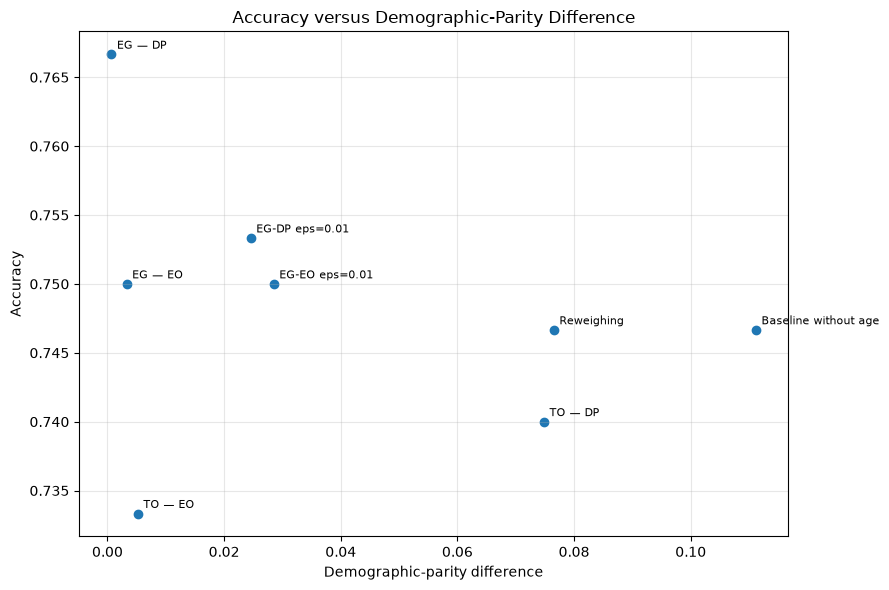

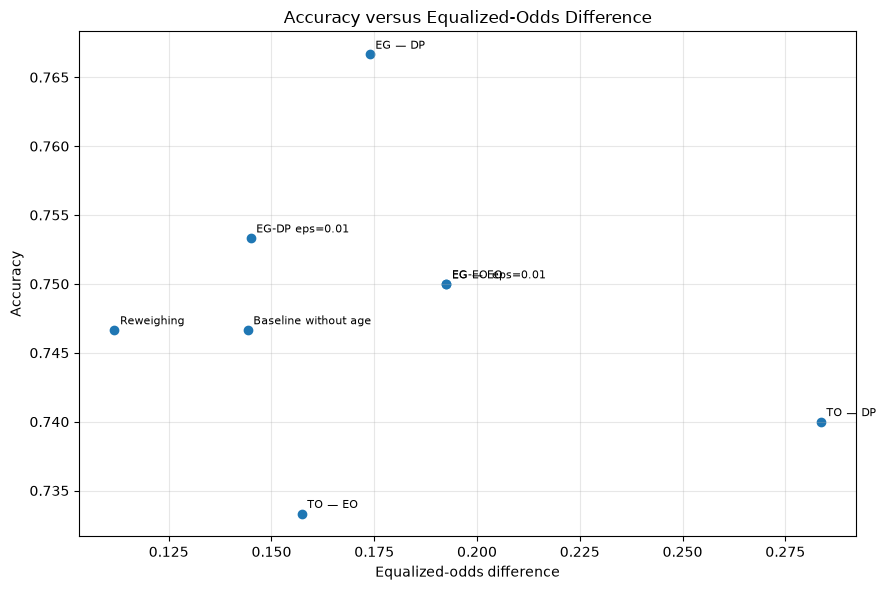

In [55]:
def plot_accuracy_frontier(
    table: pd.DataFrame,
    fairness_column: str,
    output_path: Path,
    title: str,
    x_label: str,
) -> None:
    """Create and save one fairness-accuracy frontier plot."""

    plot_table = table.sort_values(fairness_column).copy()

    fig, ax = plt.subplots(figsize=(9, 6))

    ax.scatter(
        plot_table[fairness_column],
        plot_table["accuracy"],
    )

    for _, row in plot_table.iterrows():
        label = row["method"]

        if len(label) > 32:
            label = label.replace("ExponentiatedGradient", "EG")
            label = label.replace("ThresholdOptimizer", "TO")
            label = label.replace("DemographicParity", "DP")
            label = label.replace("EqualizedOdds", "EO")

        ax.annotate(
            label,
            (row[fairness_column], row["accuracy"]),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=8,
        )

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


dp_frontier_path = FIGURES_DIR / "mission3_dp_accuracy_frontier.png"
eo_frontier_path = FIGURES_DIR / "mission3_eo_accuracy_frontier.png"

plot_accuracy_frontier(
    table=frontier_table,
    fairness_column="DP_difference",
    output_path=dp_frontier_path,
    title="Accuracy versus Demographic-Parity Difference",
    x_label="Demographic-parity difference",
)

plot_accuracy_frontier(
    table=frontier_table,
    fairness_column="EO_difference",
    output_path=eo_frontier_path,
    title="Accuracy versus Equalized-Odds Difference",
    x_label="Equalized-odds difference",
)

In [56]:
print(f"Saved: {dp_frontier_path.relative_to(PROJECT_ROOT)}")
print(f"Saved: {eo_frontier_path.relative_to(PROJECT_ROOT)}")

Saved: outputs/figures/mission3_dp_accuracy_frontier.png
Saved: outputs/figures/mission3_eo_accuracy_frontier.png


In [57]:
# Identify best observed operating points under different criteria.
# These are not automatic normative choices. They are only aids.

best_accuracy = mission3_model_comparison.sort_values(
    "accuracy",
    ascending=False,
).iloc[0]

best_dp = mission3_model_comparison.sort_values(
    "DP_difference",
    ascending=True,
).iloc[0]

best_eo = mission3_model_comparison.sort_values(
    "EO_difference",
    ascending=True,
).iloc[0]

print("Best observed accuracy among main methods:")
display(best_accuracy.to_frame().T)

print("Smallest observed demographic-parity difference among main methods:")
display(best_dp.to_frame().T)

print("Smallest observed equalized-odds difference among main methods:")
display(best_eo.to_frame().T)

Best observed accuracy among main methods:


,method,fairness_family_targeted,accuracy,selection_rate,DP_difference,EO_difference,old_TPR,young_TPR,TPR_gap_abs,old_FPR,young_FPR,FPR_gap_abs,old_PPV,young_PPV,notes
2,ExponentiatedGradient — DemographicParity,Independence,0.766667,0.786667,0.000673,0.173913,0.896739,0.884615,0.012124,0.492754,0.666667,0.173913,0.829146,0.621622,In-processing constraint targeting demographic...


Smallest observed demographic-parity difference among main methods:


,method,fairness_family_targeted,accuracy,selection_rate,DP_difference,EO_difference,old_TPR,young_TPR,TPR_gap_abs,old_FPR,young_FPR,FPR_gap_abs,old_PPV,young_PPV,notes
2,ExponentiatedGradient — DemographicParity,Independence,0.766667,0.786667,0.000673,0.173913,0.896739,0.884615,0.012124,0.492754,0.666667,0.173913,0.829146,0.621622,In-processing constraint targeting demographic...


Smallest observed equalized-odds difference among main methods:


,method,fairness_family_targeted,accuracy,selection_rate,DP_difference,EO_difference,old_TPR,young_TPR,TPR_gap_abs,old_FPR,young_FPR,FPR_gap_abs,old_PPV,young_PPV,notes
1,Reweighing,Pre-processing / distribution balancing,0.746667,0.766667,0.076528,0.111801,0.880435,0.769231,0.111204,0.507246,0.619048,0.111801,0.822335,0.606061,Changes sample weights in training.


## Mission 3 interpretation questions

Da and Ma must now answer:

1. Which method most reduced demographic-parity difference?
2. What happened to equalized-odds difference for that method?
3. Which method most reduced equalized-odds difference?
4. What happened to demographic-parity difference for that method?
5. Which method had the highest accuracy?
6. Which methods reduced accuracy?
7. Did any method improve both fairness gaps without cost?
8. Which method requires group membership at prediction time?
9. Which method changes the training distribution?
10. Which method imposes a fairness constraint during training?

The final report must not say simply that a method is "fairer."
It must name the fairness family and the cost.